|                |   |
:----------------|---|
| **Nombres**     | Jocelyn Jiménez
| **Fecha**      | 14/05/26  |

# **Conceptos**

**GINI**

En un problema de clasificación lo que se busca es obtener nodos puros, los cuales significan que todos los datos pertenecen a una sola categoría. Por lo tanto, el índice GINI es una medida que se usa en particiones de árboles de clasificación para medir que tan puro o mezclado se encuentran los datos con respecto a las clases que contiene.

Esta medida ayuda al árbol a decidir cuál es la mejor variable y punto de corte para separar las clases de manera más eficiente. Mientras más pequeño sea el resultado de GINI significa que el nodo es más puro.

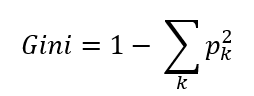

Donde:
- pi, representa la probabilidad de cada clase.
- k, número total de clases

**Entropía**

La entropía es una medida que se usa en árboles de clasificación con el objetivo de medir el nivel de incertidumbre que hay dentro del nodo. Es decir, el identificar que tan mezclados se encuentran los datos respecto a las clases.

Si la entropía es baja nos dice que la mayoría de los datos pertenecen a una sola categoría, minetras que si el resutlado es alto nos dice que las todas las clases estan distribuidas de igual forma.




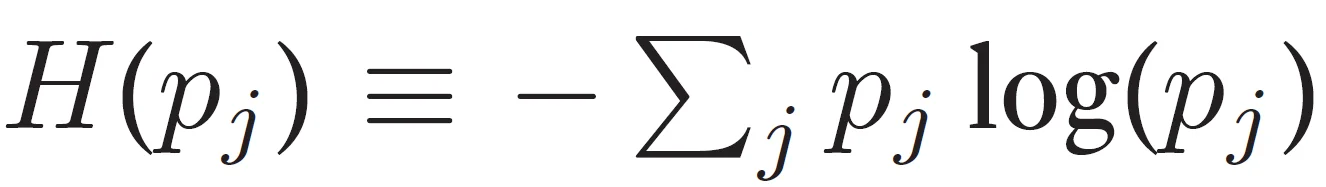

Donde:
- pi, representa la probabilidad de cada clase.
- k, número total de clases

**Log Loss**

Log Loss también conocido como pérdida logarítmica, es una medida que se usa para evaluar que tan buenas son las predicciones de un modelo y de igual forma, considera el nivel de confianza con el que se realizaron las predicciones. Por lo tanto, este método penaliza las predicciones incorrectas del modelo, aunque este estuviera seguro de sus respuestas.

Log Loss ayuda a seleccionar divisiones que mejoren la capacidad del árbol para estimar de forma correcta las probabilidades de clasificación y disminuir la incertidumbre en cada nodo. Cuando un nodo tiene datos de una sola clase, la entropía tiene un resultado bajo, pero si las clases están muy mezcladas el resultado es alto.

En los árboles de clasificación se usa como criterio para evaluar la calidad de una partición. El algoritmo busca divisiones que generen nodos donde las probabilidades de pertenecer a cada clase sean más claras y precisas.

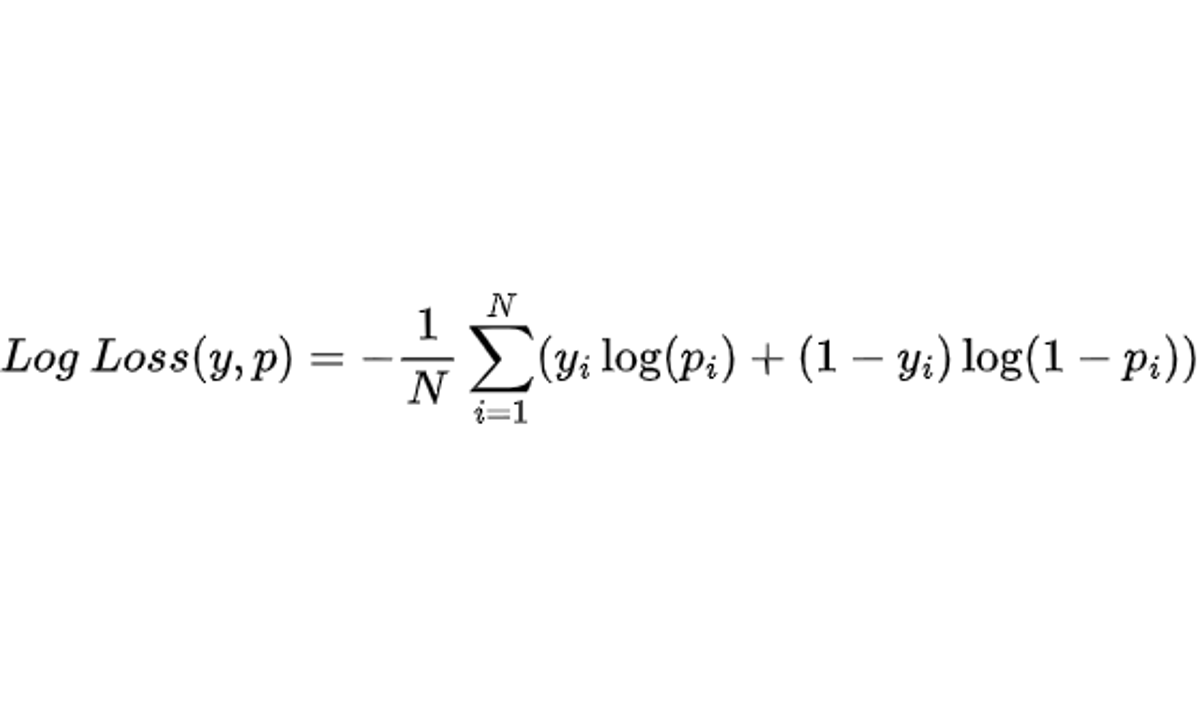

Donde:
- y, valor real de la clase
- p, probabilidad predicha para la clase positiva

**¿Cuál es la diferencia entre entropía y log loss?**

La ***entropía mide el desorden o incertidumbre*** dentro de un nodo, mediante la evaluación de las clases para ver que tan mezcladas se encuentran y así obtener cuál es la mejor partición. Por el otro lado, el ***Log Loss pone mayor atención a la calidad de las probabilidades utilizadas para realizar la clasificación.***


# **Práctico**

Escoge un dataset y realiza el ejemplo de hacer una partición para cada uno de los criterios de decisión.


In [1]:
from google.colab import files
import pandas as pd
uploaded = files.upload()
df = pd.read_csv('Default.csv')

Saving Default.csv to Default.csv


In [2]:
df.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138950
3,No,No,529.250605,35704.493940
4,No,No,785.655883,38463.495880


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   default  10000 non-null  object 
 1   student  10000 non-null  object 
 2   balance  10000 non-null  float64
 3   income   10000 non-null  float64
dtypes: float64(2), object(2)
memory usage: 312.6+ KB


In [4]:
df["default"] = df["default"].map({"No":0, "Yes":1})
df["student"] = df["student"].map({"No":0, "Yes":1})

In [5]:
X = df[["balance", "income", "student"]]
y = df["default"]

`Ejemplo GINI`

In [7]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

In [8]:
arb_gini = DecisionTreeClassifier(
    criterion="gini",
    max_depth=1,
    random_state=42
)

arb_gini.fit(X, y)

DecisionTreeClassifier(max_depth=1, random_state=42)

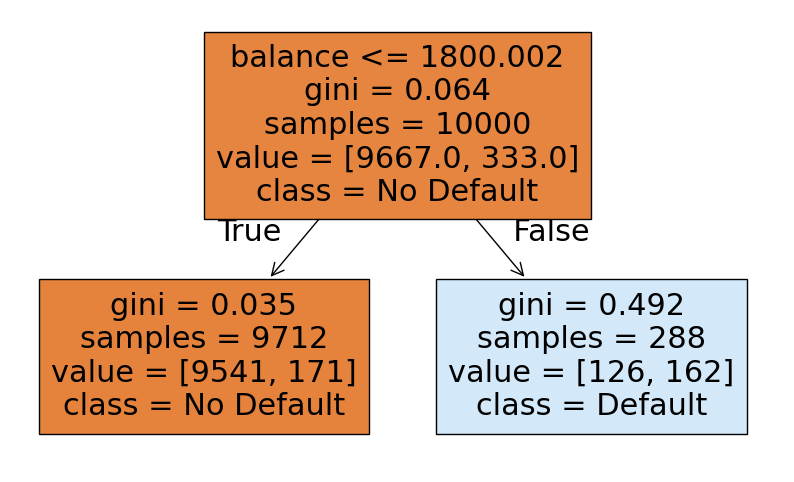

In [9]:
plt.figure(figsize=(10,6))

plot_tree(
    arb_gini,
    feature_names=X.columns,
    class_names=["No Default", "Default"],
    filled=True
)

plt.show()

**Interpretación**

GINI realizó una primera partición con la variable balance (balance <=1800) separando los datos en dos clases respecto a la variable "default". Este nodo incial cuenta con 1000 observaciones  en donde 9667 si cumplen y 333 no cumplen con el pago. Cuenta con un gini de 0.064, lo que nos dice que el nivel de impureza es bajo dándonos una clase "No default".

Después realiza otra partición en donde (TRUE) se cumple (balance <=1800) o (FALSE) no cumple (balance <=1800). En el nodo de la izquierda se presenta un (gini = 0.035) clasificando la clase como no "Default" debido a su bajo valor de gini. Por el otro lado, en el nodo derecho cuenta con un (gini = 0.492) el cual es un valor alto lo cual nos dice que tenemos una clase "Deafult·.


`Ejemplo Entropía`




In [10]:
arb_entropy = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=1,
    random_state=42
)

arb_entropy.fit(X, y)

DecisionTreeClassifier(criterion='entropy', max_depth=1, random_state=42)

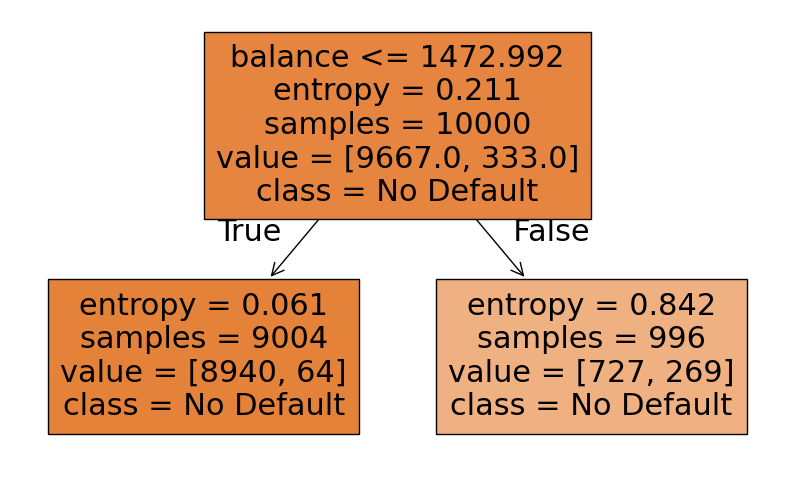

In [11]:
plt.figure(figsize=(10,6))

plot_tree(
    arb_entropy,
    feature_names=X.columns,
    class_names=["No Default", "Default"],
    filled=True
)

plt.show()

**Interpretación**

De igual forma, Entropy realizó una primera partición con la variable balance (balance <=1472.992) separando los datos en dos clases Default y No Default. En este nodo hay 10000 observaciones, en donde 9667 si cumplen y 333 no cumplen con el pago. Cuenta con un entropy de 0.211, lo que nos dice que hay cierta incertidumbre aunque se nota que la clase No Default tiene una mayor cantidad de datos (9667).

Después realiza otra partición en donde (TRUE) se cumple (balance <=1472.9) o (FALSE) no cumple (balance <=1472.9). En el nodo de la izquierda se presenta un (entropy = 0.061) clasificando la clase como no "Default" debido a su bajo valor de entropy y esto nos dice que hay muy baja incertidumbre y un grupo homogéneo. Por el otro lado, en el nodo derecho cuenta con un (entropy = 0.842) el cual es un valor alto y nos dice que la clase principal sigue siendo No Default. Esto ocurre porque después de la partición, la cantidad de clientes que no incumplen pagos sigue siendo mayoritaria en ambos grupos.


`Ejemplo Log Loss`

In [12]:
arb_log = DecisionTreeClassifier(
    criterion="log_loss",
    max_depth=1,
    random_state=42
)

arb_log.fit(X, y)

DecisionTreeClassifier(criterion='log_loss', max_depth=1, random_state=42)

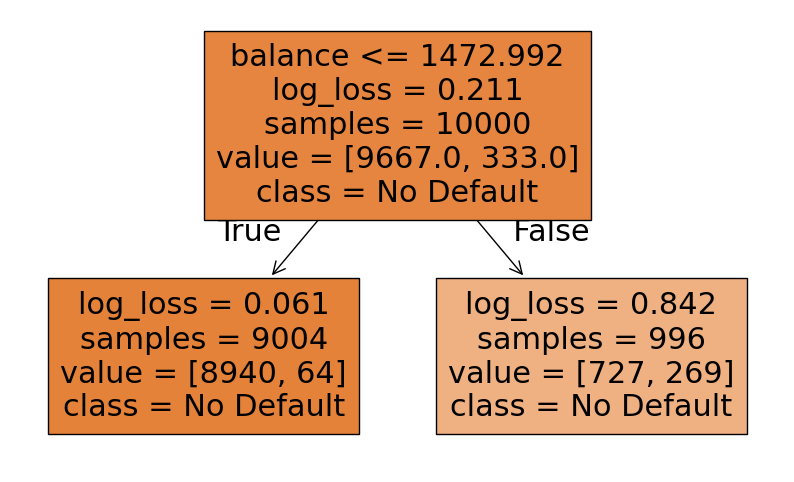

In [14]:
plt.figure(figsize=(10,6))

plot_tree(
    arb_log,
    feature_names=X.columns,
    class_names=["No Default", "Default"],
    filled=True
)

plt.show()

Como se puede observar, los criterios de Entrpy y Log Loss generaron la misma partición, esto sucede porque ambos criterios estan basados en probabilidades y usa logaritmos para medir la incertidumbre y predicciones.

**Interpretación**

De igual forma, Log Loss realizó una primera partición con la variable balance (balance <=1472.992) separando los datos en dos clases Default y No Default. En este nodo hay 10000 observaciones, en donde 9667 si cumplen y 333 no cumplen con el pago. Cuenta con un entropy de 0.211, lo que nos dice que el nodo aún tenía observaciones de ambas categorías y que existía incertidumbre en la clasificación.

Después realiza otra partición en donde (TRUE) se cumple (balance <=1472.9) o (FALSE) no cumple (balance <=1472.9). En el nodo de la izquierda se presenta un (log loss = 0.061) clasificando la clase como "No Default", indicando una separación más clara entre las clases. Por el otro lado, en el nodo derecho cuenta con un (entropy = 0.842) el cual es un valor alto y nos dice que hay una mayor mezcla entre las categorías y una clasificación menos clara. La clase principal sigue siendo No Default. Esto ocurre porque después de la partición, la cantidad de clientes que no incumplen pagos sigue siendo mayoritaria en ambos grupos.